In [ ]:
%pip install puremacro


# Flexible trade building blocks and a benchmark equilibrium

**How do factor substitution, subsistence demand and variable markups change decisions at given prices, and who bears a tariff in a small benchmark equilibrium?**

All numbers come from a hand-balanced table with two countries and two sectors in illustrative value units; the codes A, B, FOOD and MANU do not refer to observed economies. Sections 1-3 evaluate the library's cost, demand and pricing blocks at given prices. Sections 4-6 solve a tariff equilibrium, show how its answer depends on one elasticity, and compare two accounting closures.

The bundled 77x11 table returned by `load_icio_data()` is a software regression fixture aggregated from a corrupted OECD export (numbers lost their decimal points), not a source of estimates: see the 2026-09-22 entry of [docs/ADVISORY.md](../docs/ADVISORY.md). The first code cell only reads its provenance label.

## The method in math

Hats are ratios to the benchmark: $\hat r$ and $\hat w$ are the rental rate and the wage, $\alpha$ is capital's share of value added and $\rho$ the capital-labour elasticity. Unit cost of value added under a constant elasticity of substitution (CES) and conditional factor demand:
$$\hat c_{VA}=\big[\alpha\hat r^{1-\rho}+(1-\alpha)\hat w^{1-\rho}\big]^{1/(1-\rho)},\qquad \frac{K/L}{K_0/L_0}=\Big(\frac{\hat w}{\hat r}\Big)^{\rho}.$$
Household demand is a linear expenditure system (LES; Geary 1950, Stone 1954) with an income-scaled subsistence quantity: $c_s=\bar c_s(u)+b_s\big[m-\sum_kP_k\bar c_k(u)\big]^+/P_s$ with $\bar c_s(u)=\gamma_s c_{s0}\,g(u)$ and $g(u)=\tanh(3u)/\tanh(3)$. Here $m$ is the household budget, $u$ income relative to the benchmark, $P_s$ composite prices, $c_{s0}$ benchmark quantities, $\gamma_s$ the subsistence share, $b_s$ calibrated marginal budget shares and $[\cdot]^+$ the library's clip at zero.
Cournot markups (Atkeson and Burstein 2008) at destination market share $\omega$: $\mathcal M(\omega)=\sigma_j/[\sigma_j-1+(1-\sigma_j/\theta_j)\,\omega]$, with the within-sector elasticity $\sigma_j$ above the across-sector elasticity $\theta_j$, clipped to $[1,5]$.
The benchmark equilibrium solves $\|R(x)\|_\infty\le\epsilon$ for prices, outputs, factor prices and transfers. Producer $j$ buys intermediates from one CES nest over all origin country-sectors $i$, $Z_{ij}=a_{ij}\,y_j\,\big(P_j/(p_i\tau_{ij})\big)^{\sigma}$. When A imposes the tariff $t$, the share borne by B's producers is $\iota=-\Delta\ln p_B/\ln(1+t)$ with A's food price as numeraire, and a country's terms of trade are its export over its import unit value at producer prices.

## Intuition

**Intuition.** A higher $\rho$ means firms swap labour for capital more readily when wages rise relative to rents. An income-scaled subsistence quantity makes food a necessity, so its budget share falls as income rises. When $\sigma_j>\theta_j$, a firm with a larger share of its destination market faces less elastic demand and charges a higher markup. These three blocks are evaluated at given prices and close no market. In the equilibrium, A's tariff cuts A's purchases from B; with foreign saving fixed, B's prices and wages must move until trade balances again. Final-use baskets have fixed coefficients, so A's buyers switch away from B's goods mainly through intermediates, at a speed set by $\sigma$. If they switch readily, a fall in B's prices wins back sales and B absorbs the tariff. If they switch too little, a price cut lowers B's export earnings and B's prices must rise instead: a Marshall-Lerner-type condition, at whose boundary the equilibrium response is unbounded.

## Worked code

Country A and country B each produce food (FOOD) and manufactures (MANU).

In [1]:
from pathlib import Path
from dataclasses import replace
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
colors, dashes = _nbstyle.palette(3), _nbstyle.styles(3)
from puremacro.trade import (calibrate_trade_model, compute_equilibrium_residuals,
                             solve_flexible_trade_equilibrium, solve_trade_equilibrium)
from puremacro.trade.ces_newton import NestedCESTechnology, solve_ces_block_newton
from puremacro.trade.data import load_icio_data
from puremacro.trade.flexible import (
    FlexibleTechnologyConfig, FlexiblePreferenceConfig,
    compute_nested_ces_costs, compute_nested_factor_demands,
    compute_stone_geary_final_demand, compute_atkeson_burstein_markups,
    smooth_subsistence_scaling,
)

# The bundled 77x11 table is a regression fixture (docs/ADVISORY.md): read its label, nothing else.
fixture = load_icio_data(return_structured=True)
assert fixture.metadata["is_regression_fixture"]
print("Bundled 77x11 table", fixture.matrix.shape, "->", fixture.metadata["use"])

# Rows/columns of the intermediate block: A-food, A-manufactures, B-food, B-manufactures.
Z = np.array([[10., 15., 5., 5.], [15., 20., 10., 10.],
              [5., 5., 12., 18.], [10., 10., 18., 22.]])
output0 = np.array([100., 150., 120., 180.])
# Three final uses per country (A's, then B's); both sectors of a country share one final-use mix.
final_weights = np.array([[.50, .25, .05, .10, .08, .02]] * 2 +
                         [[.10, .08, .02, .50, .25, .05]] * 2)
F = (output0 - Z.sum(axis=1))[:, None] * final_weights
production_tax = .05 * output0  # 5% of output revenue
factor_income = output0 - Z.sum(axis=0) - production_tax
labor_share = np.array([.70, .40, .60, .30])
# Row order read by calibrate_trade_model: transactions, taxes (production, then 2% on final
# uses), labour income, capital income.
table = np.vstack([np.hstack([Z, F]),
    np.r_[production_tax, .02 * F.sum(axis=0)],
    np.r_[labor_share * factor_income, np.zeros(6)],
    np.r_[(1 - labor_share) * factor_income, np.zeros(6)]])
np.testing.assert_allclose(table[:4].sum(axis=1), table[:, :4].sum(axis=0))  # sales = costs
calib = calibrate_trade_model(table, ns=2, nc=2, nfd=3,
    country_codes=["A", "B"], sector_codes=["FOOD", "MANU"])
calib = replace(calib, metadata={**calib.metadata, "is_synthetic": True,
    "source": "hand-balanced teaching table", "unit": "illustrative value units"})
print({key: calib.metadata[key] for key in ("source", "unit", "is_synthetic")})

Bundled 77x11 table (850, 1078) -> MATLAB-parity regression fixture; do not report outputs computed from it as OECD-based estimates
{'source': 'hand-balanced teaching table', 'unit': 'illustrative value units', 'is_synthetic': True}


### 1. Conditional factor substitution

Hold rental rates, intermediate prices and output fixed and vary the wage relative to the rental rate. The curves show capital per worker in A's manufacturing; the assert checks the power law in every sector and country.

rho = 0.7: capital per worker at w/r = 1.2 is 1.136 x baseline
rho = 1.0: capital per worker at w/r = 1.2 is 1.200 x baseline
rho = 1.4: capital per worker at w/r = 1.2 is 1.291 x baseline


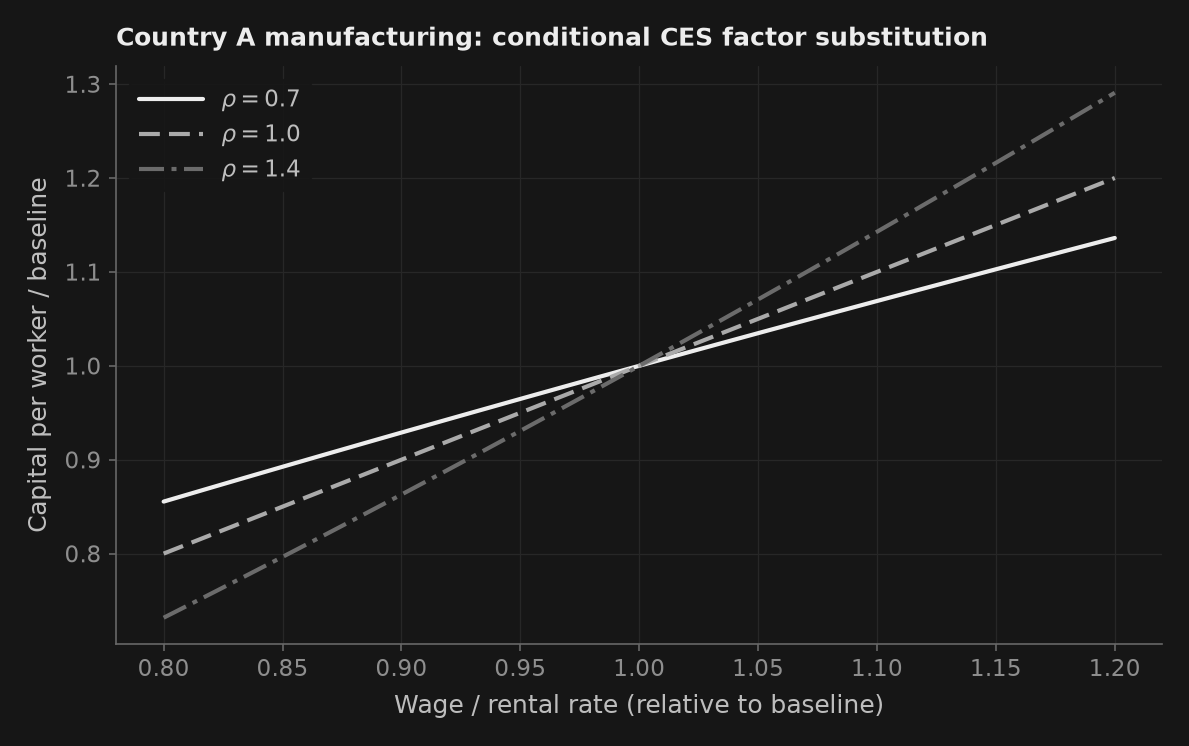

In [2]:
ones = np.ones((1, calib.n_sectors, calib.n_countries))  # unit goods prices
factor_ones = np.ones((1, 1, calib.n_countries))  # unit factor prices
# No tariffs; axes are (origin country-sector, using sector, destination country).
tau_ones = np.ones((calib.n_sectors * calib.n_countries, calib.n_sectors, calib.n_countries))
wage_ratios = np.linspace(.8, 1.2, 25)
elasticities = (.7, 1., 1.4)
fig, ax = plt.subplots(figsize=(9, 5))
for rho, color, dash in zip(elasticities, colors, dashes):
    tech = FlexibleTechnologyConfig(rho_va=rho, sigma_y=.2)

    def capital_per_worker(wage_ratio):
        # Only the wage moves: rental rates, intermediate prices and output stay at the benchmark.
        wages = factor_ones * wage_ratio
        c_va, c_y = compute_nested_ces_costs(r=factor_ones, w=wages, P_M=ones, calib=calib, tech_cfg=tech)
        labor, capital, _ = compute_nested_factor_demands(
            calib.ytot, r=factor_ones, w=wages, P_M=ones, c_va=c_va, c_y=c_y, p=ones,
            tau=tau_ones, calib=calib, tech_cfg=tech, normalized=True)
        return capital / labor

    kl0 = capital_per_worker(1.)
    ratios = np.array([capital_per_worker(x) / kl0 for x in wage_ratios])
    # Every sector and country obeys (K/L)/(K0/L0) = (w/r)^rho, whatever its capital share or sigma_y.
    np.testing.assert_allclose(ratios, np.broadcast_to(wage_ratios[:, None, None, None] ** rho, ratios.shape),
                               rtol=1e-10)
    print(f"rho = {rho:.1f}: capital per worker at w/r = {wage_ratios[-1]:.1f} is "
          f"{ratios[-1, 0, 1, 0]:.3f} x baseline")
    ax.plot(wage_ratios, ratios[:, 0, 1, 0], color=color, linestyle=dash, label=rf"$\rho = {rho:.1f}$")
ax.set(xlabel="Wage / rental rate (relative to baseline)", ylabel="Capital per worker / baseline",
       title="Country A manufacturing: conditional CES factor substitution")
ax.legend()

### 2. Demand at fixed prices

Compare zero subsistence with a food subsistence share $\gamma=0.30$: 30% of the benchmark food quantity, scaled by $g(u)$, forms the subsistence component, not 30% of income. Because $g(u)>u$ for $0<u<1$, subsistence spending falls more slowly than income. If it ever exceeded the budget, the library would clip supernumerary income at zero and return a bundle that overspends, with a `RuntimeWarning`; at unit prices that can happen at some income only if $\sum_s\gamma_s s_{s0}$ (benchmark budget shares $s_{s0}$) exceeds $\tanh(3)/3$. The cell prints that sum, the ratio of subsistence spending to the budget on the grid, and checks budget exhaustion. This income-scaled rule is not derived from a utility function (its Slutsky matrix is asymmetric; see [docs/trade_household.md](../docs/trade_household.md)), so it yields Engel curves but no welfare measure.

A's benchmark food share s0 = 0.405; gamma * s0 = 0.121 against tanh(3)/3 = 0.332
Subsistence spending / budget: 0.068 to 0.193 on the grid, 0.366 in the limit of zero income
Zero subsistence: food share 40.5% at income x0.6, 40.5% at x1.8
Food subsistence share 0.30: food share 45.3% at income x0.6, 36.9% at x1.8


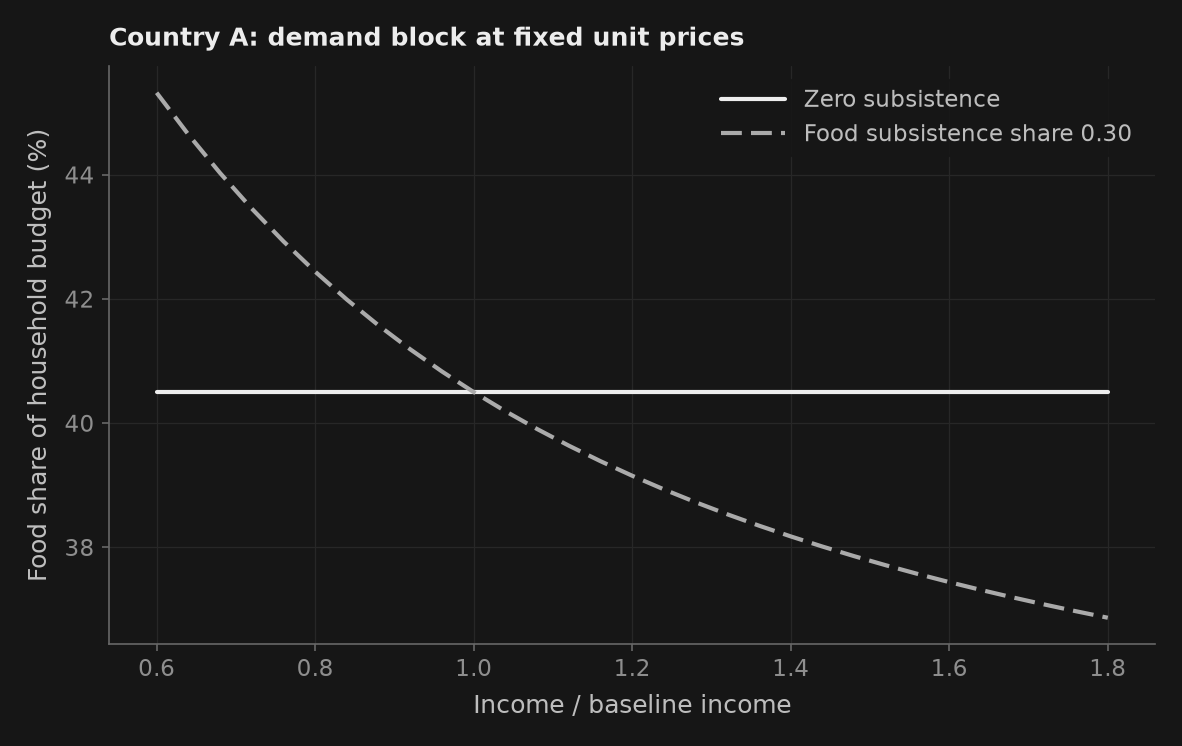

In [3]:
income0 = (calib.l_endow + calib.k_endow + calib.T).reshape(1, 1, 2)  # benchmark consumer income
household_share = calib.theta[:, :1, :]  # household budget as a share of income
income_ratios = np.linspace(.6, 1.8, 31)
gamma_food = .30
preferences = {"Zero subsistence": FlexiblePreferenceConfig(),
               f"Food subsistence share {gamma_food:.2f}":
                   FlexiblePreferenceConfig(subsistence_shares={"FOOD": gamma_food})}
# Benchmark food quantity of country A (unit prices, so quantity = spending).
food0 = compute_stone_geary_final_demand(income0, ones, calib, FlexiblePreferenceConfig())[0, 0, 0]
food_share0 = food0 / (household_share * income0)[0, 0, 0]
# Subsistence spending over the budget at income ratio u: gamma * s0 * g(u) / u.
subsistence_ratio = gamma_food * food_share0 * smooth_subsistence_scaling(income_ratios) / income_ratios
assert subsistence_ratio.max() < 1  # the clip at zero never binds on this grid
print(f"A's benchmark food share s0 = {food_share0:.3f}; gamma * s0 = {gamma_food * food_share0:.3f} "
      f"against tanh(3)/3 = {np.tanh(3) / 3:.3f}")
print(f"Subsistence spending / budget: {subsistence_ratio.min():.3f} to {subsistence_ratio.max():.3f} "
      f"on the grid, {gamma_food * food_share0 * 3 / np.tanh(3):.3f} in the limit of zero income")
fig, ax = plt.subplots(figsize=(9, 5))
for (label, pref), color, dash in zip(preferences.items(), colors, dashes):
    food_shares = []
    for income_ratio in income_ratios:
        income = income_ratio * income0
        demand = compute_stone_geary_final_demand(income, ones, calib, pref)
        household_budget = household_share * income
        np.testing.assert_allclose(demand.sum(axis=1, keepdims=True), household_budget, rtol=1e-10)
        food_shares.append(100 * demand[0, 0, 0] / household_budget[0, 0, 0])
    print(f"{label}: food share {food_shares[0]:.1f}% at income x{income_ratios[0]:.1f}, "
          f"{food_shares[-1]:.1f}% at x{income_ratios[-1]:.1f}")
    ax.plot(income_ratios, food_shares, color=color, linestyle=dash, label=label)
    if pref.subsistence_shares:
        assert food_shares[0] > food_shares[-1]  # food behaves as a necessity
ax.set(xlabel="Income / baseline income", ylabel="Food share of household budget (%)",
       title="Country A: demand block at fixed unit prices")
ax.legend()

### 3. Markups at given market shares

Evaluate the library's Cournot pricing function with $\sigma_j=5$ and $\theta_j=2$. The curve maps an assumed market share to a markup; it does not solve for the share after a tariff. Holding marginal cost fixed, a fall in share from 0.30 to 0.20 lowers the markup and so the price. No pass-through percentage is imposed or presented as a model estimate.

Share 0.30 -> 0.20: markup 1.4085 -> 1.3514; price at unchanged cost x0.9595 (4.05% lower)


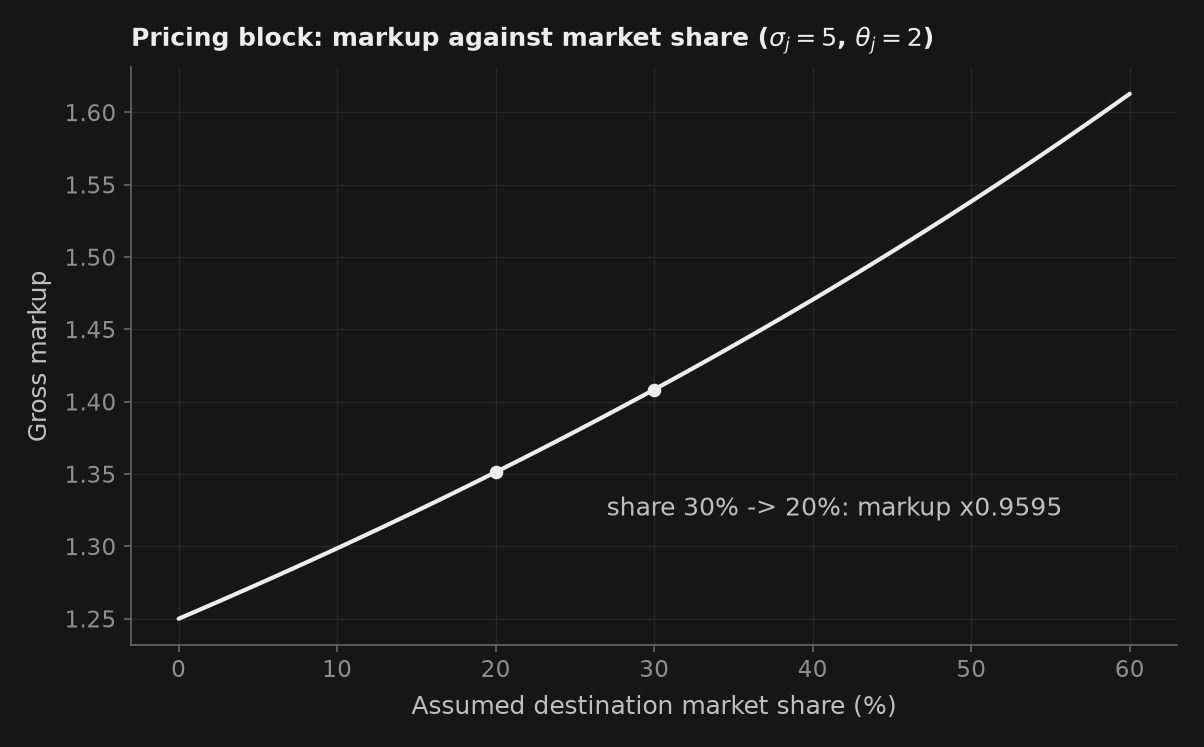

In [4]:
market_shares = np.linspace(0., .6, 61)
sigma_j, theta_j = 5., 2.  # within-sector elasticity above the across-sector one
markups, _ = compute_atkeson_burstein_markups(market_shares, sigma_j=sigma_j, theta_j=theta_j)
np.testing.assert_allclose(markups, sigma_j / (sigma_j - 1 + (1 - sigma_j / theta_j) * market_shares))
assert np.all(np.diff(markups) > 0)  # larger share, less elastic residual demand, higher markup
initial_markup, _ = compute_atkeson_burstein_markups(np.array([.30]), sigma_j=sigma_j, theta_j=theta_j)
# With mu_0 given, the function returns the price at the unchanged marginal cost c_i = 1.
new_markup, relative_price = compute_atkeson_burstein_markups(np.array([.20]),
    c_i=np.ones(1), mu_0=initial_markup, sigma_j=sigma_j, theta_j=theta_j)
markup_ratio = float(new_markup[0] / initial_markup[0])
np.testing.assert_allclose(relative_price, markup_ratio)
print(f"Share 0.30 -> 0.20: markup {initial_markup[0]:.4f} -> {new_markup[0]:.4f}; "
      f"price at unchanged cost x{markup_ratio:.4f} ({100 * (1 - markup_ratio):.2f}% lower)")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(100 * market_shares, markups, color=colors[0])
ax.plot([30, 20], [initial_markup[0], new_markup[0]], linestyle="none", marker="o", color=colors[0])
ax.annotate(f"share 30% -> 20%: markup x{markup_ratio:.4f}", xy=(25, new_markup[0]),
            xytext=(27, new_markup[0] - .03), color=_nbstyle.TEXTO)
ax.set(xlabel="Assumed destination market share (%)", ylabel="Gross markup",
       title=rf"Pricing block: markup against market share ($\sigma_j={sigma_j:g}$, $\theta_j={theta_j:g}$)")

### 4. A benchmark tariff equilibrium

`solve_trade_equilibrium` with consistent accounting ([docs/trade_accounting.md](../docs/trade_accounting.md)): trade valued at producer prices, duties rebated lump sum, foreign saving fixed in units of A-FOOD, the numeraire. Each producer buys intermediates from a single CES nest with $\sigma=2$ over all four origin country-sectors, so $\sigma$ also governs substitution between FOOD and MANU inputs. Final-use baskets have fixed coefficients, and each final-use category spends a fixed share of income (investment net of foreign saving). Country A taxes all imports from B at 10%, in intermediate and final use. $\sigma=2$ is illustrative, not an estimate; section 5 varies it. This solve does not use the blocks of sections 1-3.

In [5]:
# Consistent accounting: producer-price trade, duties rebated lump sum, foreign saving fixed in
# units of A-FOOD (the numeraire), one CES nest with elasticity sigma over all origin cells.
ge_options = dict(method="newton", accounting="consistent", sigma=2., tol=1e-8, max_iter=80)


def solve_tariff(sigma, tariff, **extra):
    """Baseline and counterfactual when A taxes all imports from B at the rate `tariff`."""
    options = {**ge_options, "sigma": sigma, **extra}
    rates = np.array([tariff, 0.])  # ad valorem rates by importing country, not multipliers
    start = solve_trade_equilibrium(calib, **options)
    result = solve_trade_equilibrium(calib, tau=rates, tau_fd=rates, base_result=start, **options)
    for solved in (start, result):
        assert solved.converged and solved.max_residual <= options["tol"]
    return start, result


def incidence_on_b(start, result, tariff):
    """Share of A's log tariff absorbed by the fall in B's producer prices (A-FOOD fixed at 1)."""
    return -np.log(result.p_sol[0, :, 1] / start.p_sol[0, :, 1]) / np.log1p(tariff)


tariff = .10
base, counterfactual = solve_tariff(2., tariff)
print(f"Maximum residual: baseline {base.max_residual:.1e}, counterfactual {counterfactual.max_residual:.1e}")
sector_labels = [f"{country}-{sector}" for country in calib.country_codes for sector in calib.sector_codes]
price_changes = 100 * (counterfactual.p_sol / base.p_sol - 1).ravel(order="F")
output_changes = 100 * (counterfactual.y_sol / base.y_sol - 1).ravel(order="F")
print(pd.DataFrame({"producer price (%)": price_changes, "gross output (%)": output_changes},
                   index=sector_labels).round(3).to_string())
incidence = incidence_on_b(base, counterfactual, tariff)
landed = (1 + tariff) * counterfactual.p_sol[0, :, 1] / base.p_sol[0, :, 1]
tot_a, tot_b = counterfactual.terms_of_trade
wage_change = 100 * (counterfactual.w_sol / base.w_sol - 1).ravel()
rent_change = 100 * (counterfactual.r_sol / base.r_sol - 1).ravel()
print("Tariff-inclusive price of B's goods in A (baseline 1): FOOD {:.4f}, MANU {:.4f}".format(*landed))
print("Share of the tariff borne by B's producer prices: FOOD {:.3f}, MANU {:.3f}".format(*incidence))
print(f"Terms of trade (export / import unit value): A {tot_a:.4f}, B {tot_b:.4f}")
print("Wages (%): A {:+.3f}, B {:+.3f}; rental rates (%): A {:+.3f}, B {:+.3f}".format(*wage_change, *rent_change))
assert price_changes[0] == 0  # A-FOOD is the numeraire
# Headline: B bears roughly all of the tariff, and A's terms of trade rise by about 1 + t.
assert np.all((incidence > .9) & (incidence < 1.1)) and abs(np.log(tot_a) / np.log1p(tariff) - 1) < .01
# Closure check: foreign saving fixed as a share of world factor income instead of in A-FOOD units.
world = incidence_on_b(*solve_tariff(2., tariff, foreign_saving_units="world_income"), tariff)
print("Same shares with foreign saving fixed as a share of world income: FOOD {:.3f}, MANU {:.3f}".format(*world))

Maximum residual: baseline 2.8e-14, counterfactual 4.8e-12
        producer price (%)  gross output (%)
A-FOOD               0.000             0.276
A-MANU              -0.023            -0.164
B-FOOD              -8.807            -0.129
B-MANU              -9.269             0.077
Tariff-inclusive price of B's goods in A (baseline 1): FOOD 1.0031, MANU 0.9980
Share of the tariff borne by B's producer prices: FOOD 0.967, MANU 1.021
Terms of trade (export / import unit value): A 1.0999, B 0.9092
Wages (%): A +0.054, B -10.499; rental rates (%): A -0.081, B -10.440
Same shares with foreign saving fixed as a share of world income: FOOD 0.907, MANU 0.957


### 5. How much of the tariff B bears depends on $\sigma$

Repeat the 10% solve over a grid of $\sigma$, and locate the $\sigma$ at which the Jacobian of the equilibrium system at the benchmark is singular. The grid skips the interval between 0.8 and 1.2 around that point.

       B-FOOD  B-MANU  A terms of trade
sigma                                  
0.0     0.029   0.028             0.998
0.5    -0.446  -0.473             0.951
0.8    -2.048  -2.163             0.806
1.2     2.951   3.126             1.349
2.0     0.967   1.021             1.100
5.0     0.616   0.648             1.061
det J changes sign at sigma* = 0.9892; Newton at sigma = 1 converged: False


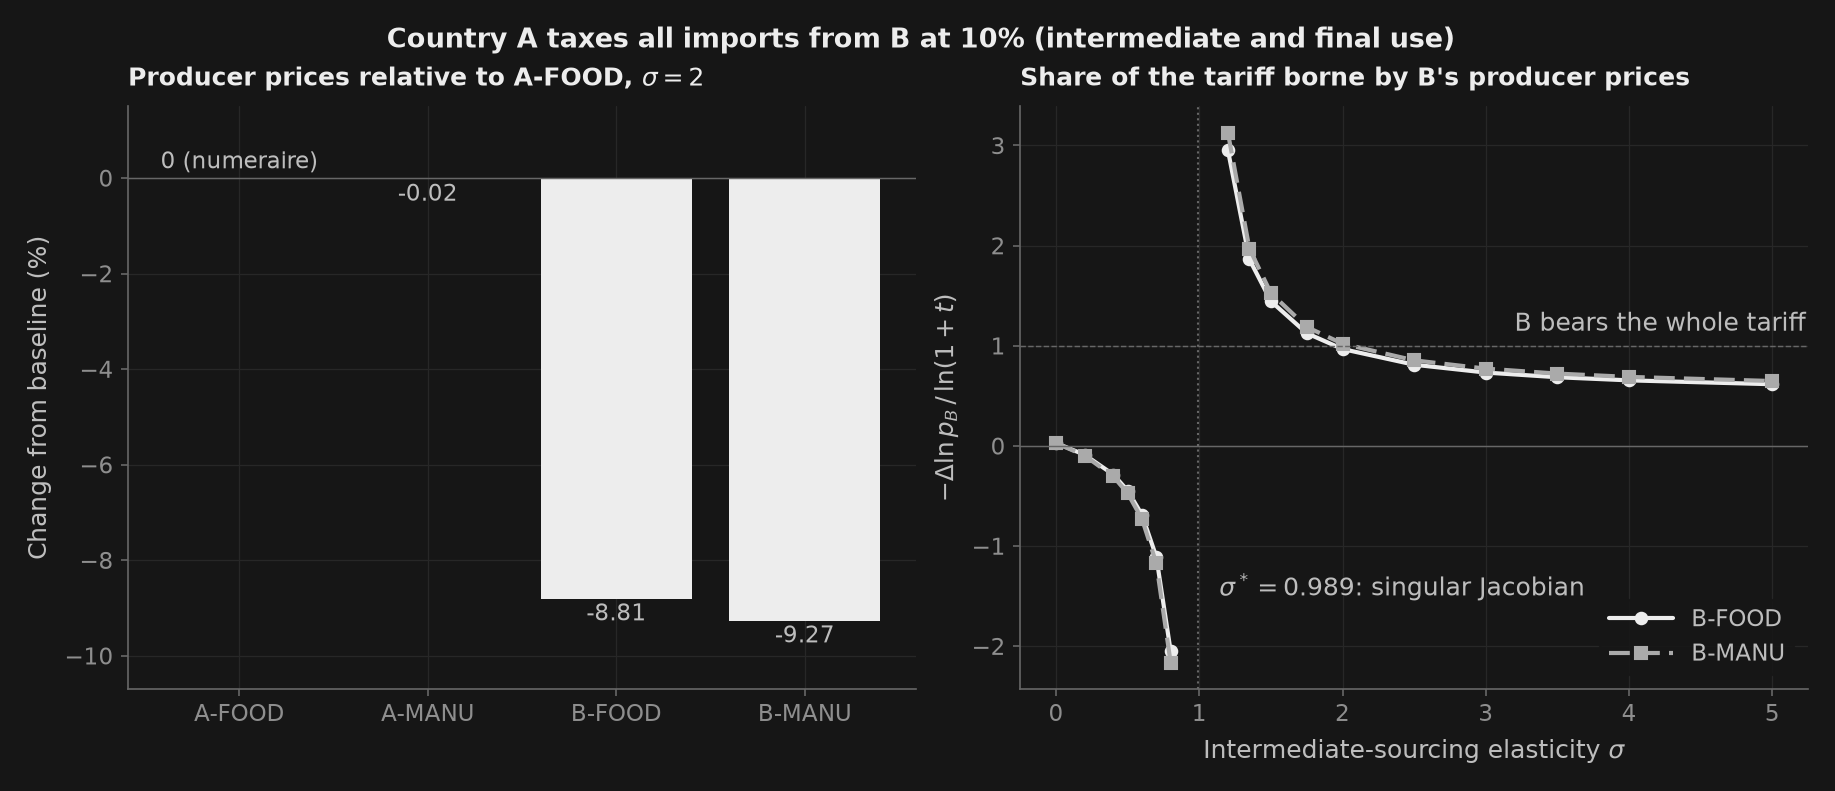

In [6]:
sigma_grid = np.r_[0., .2, .4, .5, .6, .7, .8, 1.2, 1.35, 1.5, 1.75, 2., 2.5, 3., 3.5, 4., 5.]
share_columns = ["B-FOOD", "B-MANU"]
sweep = pd.DataFrame(index=pd.Index(sigma_grid, name="sigma"),
                     columns=[*share_columns, "A terms of trade"], dtype=float)
for sigma in sigma_grid:
    start, result = solve_tariff(sigma, tariff)
    sweep.loc[sigma] = [*incidence_on_b(start, result, tariff), result.terms_of_trade[0]]
print(sweep.loc[[0., .5, .8, 1.2, 2., 5.]].round(3).to_string())

# The benchmark state is the same for every sigma, so the Jacobian there depends on sigma alone.
x0 = base.x_sol.ravel()


def benchmark_jacobian(sigma, h=1e-6):
    residual = lambda x: compute_equilibrium_residuals(x, calib, sigma=sigma, accounting="consistent")
    return np.column_stack([(residual(x0 + h * e) - residual(x0 - h * e)) / (2 * h)
                            for e in np.eye(x0.size)])


sigma_star = brentq(lambda s: np.linalg.det(benchmark_jacobian(s)), .9, 1.05, xtol=1e-6)
# Symptom, not a check: from the benchmark start, Newton does not find the 10% equilibrium near sigma*.
near_options = {**ge_options, "sigma": 1.}
near = solve_trade_equilibrium(calib, tau=np.array([tariff, 0.]), tau_fd=np.array([tariff, 0.]),
                               base_result=solve_trade_equilibrium(calib, **near_options), **near_options)
print(f"det J changes sign at sigma* = {sigma_star:.4f}; Newton at sigma = 1 converged: {near.converged}")
assert np.all(np.abs(sweep.loc[0., share_columns]) < .05)  # nothing substitutes: B's prices barely move
assert np.all(sweep.loc[.5, share_columns] < 0) and np.all(sweep.loc[2., share_columns] > 0)
above = sweep.loc[sweep.index > sigma_star, share_columns].to_numpy()
assert np.all(np.diff(above, axis=0) < 0)  # above sigma*, easier substitution shifts less onto B

fig, (ax_price, ax_share) = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
fig.suptitle(f"Country A taxes all imports from B at {100 * tariff:.0f}% (intermediate and final use)")
ax_price.bar(sector_labels, price_changes, color=colors[0])
ax_price.axhline(0, color=_nbstyle.SPINE, linewidth=.7)
bar_labels = _nbstyle.etiquetar_barras(ax_price, fmt="{:.2f}")
bar_labels[0].set_text("0 (numeraire)")
ax_price.set_ylim(1.1 * price_changes.min() - .5, 1.5)
ax_price.set(title=r"Producer prices relative to A-FOOD, $\sigma=2$", ylabel="Change from baseline (%)")
for column, color, dash, marker in zip(share_columns, colors, dashes, ["o", "s"]):
    for side, label in ((sweep.index < sigma_star, column), (sweep.index > sigma_star, None)):
        ax_share.plot(sweep.index[side], sweep.loc[side, column], color=color, linestyle=dash,
                      marker=marker, label=label)
ax_share.axhline(1, color=_nbstyle.SPINE, linewidth=.7, linestyle="--")
ax_share.axhline(0, color=_nbstyle.SPINE, linewidth=.7)
ax_share.axvline(sigma_star, color=_nbstyle.SPINE, linewidth=1, linestyle=":")
ax_share.annotate("B bears the whole tariff", xy=(3.2, 1), xytext=(3.2, 1.15), color=_nbstyle.TEXTO)
ax_share.annotate(rf"$\sigma^*={sigma_star:.3f}$: singular Jacobian", xy=(sigma_star, -1.5),
                  xytext=(sigma_star + .15, -1.5), color=_nbstyle.TEXTO)
ax_share.set(title="Share of the tariff borne by B's producer prices",
             xlabel=r"Intermediate-sourcing elasticity $\sigma$", ylabel=r"$-\Delta\ln p_B\,/\,\ln(1+t)$")
ax_share.legend(loc="lower right")

### 6. The closure or the flexible blocks?

`solve_flexible_trade_equilibrium` puts the blocks of sections 1-3 into general equilibrium, but it solves only under the legacy accounting closure: it has no consistent-accounting option. For the technology blocks alone ($\rho_{va}$, $\sigma_{inter}$), `solve_ces_block_newton` solves the same nested CES under consistent accounting. Solving the 10% tariff both ways, with $\sigma_{inter}=2$ as in section 4, separates the effect of the closure from that of $\rho_{va}$. The table reports each price of B relative to A-FOOD, so the two closures are compared on the same footing.

In [7]:
def relative_to_a_food(result, baseline):
    """Percent change of each producer price relative to A-FOOD, comparable across closures."""
    ratio = (result.p_sol / baseline.p_sol).ravel(order="F")
    return 100 * (ratio / ratio[0] - 1)


no_tariff, a_tariff = np.zeros(2), np.array([tariff, 0.])
closures = {}
for rho_va in (.5, 1., 2.):
    # Consistent closure: the nested-CES technology solved by exact block Newton.
    technology = NestedCESTechnology.from_flexible(FlexibleTechnologyConfig(rho_va=rho_va, sigma_inter=2.))
    consistent = [solve_ces_block_newton(calib, r, r, technology=technology).equilibrium
                  for r in (no_tariff, a_tariff)]
    # Legacy closure: the flexible solver, which has no consistent-accounting option.
    legacy = [solve_flexible_trade_equilibrium(calib, rho_va=rho_va, sigma_inter=2., tau=r, tau_fd=r, tol=1e-10)
              for r in (no_tariff, a_tariff)]
    assert all(solved.converged for solved in consistent + legacy)
    assert legacy[1].metadata["flexible_settings_applied"]
    closures[f"rho_va = {rho_va:.1f}"] = [*relative_to_a_food(consistent[1], consistent[0])[2:],
                                          *relative_to_a_food(legacy[1], legacy[0])[2:]]
closures = pd.DataFrame(closures, index=["consistent B-FOOD", "consistent B-MANU",
                                         "legacy B-FOOD", "legacy B-MANU"]).T
print("Change in B's producer prices relative to A-FOOD (%), sigma_inter = 2:")
print(closures.round(3).to_string())
print("Legacy trade-balance valuation of final-demand trade:", legacy[1].metadata["trade_balance_valuation"])
# At rho_va = 1 each route reproduces a plain solve: section 4, and the legacy solver.
np.testing.assert_allclose(closures.iloc[1, :2], price_changes[2:], atol=1e-8)
legacy_options = dict(method="newton", accounting="legacy", replicate_matlab_precedence=False,
                      sigma=2., tol=1e-10, max_iter=80)
plain_legacy = [solve_trade_equilibrium(calib, tau=r, tau_fd=r, **legacy_options) for r in (no_tariff, a_tariff)]
np.testing.assert_allclose(closures.iloc[1, 2:], relative_to_a_food(plain_legacy[1], plain_legacy[0])[2:],
                           atol=1e-6)
# The closure flips the sign; rho_va moves each price by a small fraction of that gap.
rho_spread = (closures.max() - closures.min()).max()
print(f"Largest change of any column across rho_va (percentage points): {rho_spread:.3f}")
assert (closures.iloc[:, :2] < 0).all().all() and (closures.iloc[:, 2:] > 0).all().all()
assert rho_spread < .1
# With Leontief sourcing (sigma_inter = 0) rho_va has no effect at all on this economy.
leontief = {}
for rho_va in (.5, 2.):
    baseline, shocked = [solve_flexible_trade_equilibrium(calib, rho_va=rho_va, tau=r, tau_fd=r, tol=1e-10)
                         for r in (no_tariff, a_tariff)]
    # The output mix cannot change, so w/r stays at its baseline and rho_va never comes into play.
    assert np.abs(np.log((shocked.w_sol / shocked.r_sol) / (baseline.w_sol / baseline.r_sol))).max() < 1e-10
    leontief[rho_va] = relative_to_a_food(shocked, baseline)
np.testing.assert_allclose(leontief[.5], leontief[2.], atol=1e-8)
print("sigma_inter = 0, B's prices relative to A-FOOD (%), identical for rho_va = 0.5 and 2:",
      np.round(leontief[.5][2:], 3))

Change in B's producer prices relative to A-FOOD (%), sigma_inter = 2:
              consistent B-FOOD  consistent B-MANU  legacy B-FOOD  legacy B-MANU
rho_va = 0.5             -8.830             -9.281          1.465          1.526
rho_va = 1.0             -8.807             -9.269          1.434          1.518
rho_va = 2.0             -8.796             -9.262          1.417          1.514
Legacy trade-balance valuation of final-demand trade: ppfd_legacy
Largest change of any column across rho_va (percentage points): 0.048
sigma_inter = 0, B's prices relative to A-FOOD (%), identical for rho_va = 0.5 and 2: [1.517 1.634]


## Read the output

**Blocks at given prices.** In the first figure capital per worker in A's manufacturing follows $(w/r)^\rho$ exactly: when the wage rises 20% relative to the rental rate, it rises to 1.136, 1.200 and 1.291 times its baseline for $\rho=0.7$, 1.0 and 1.4. In the second, subsistence makes food a necessity: A's food share falls from 45.3% at 0.6 times benchmark income to 36.9% at 1.8 times, against a flat 40.5% without subsistence. Subsistence spending stays between 0.068 and 0.193 of the budget on the grid (0.366 in the limit of zero income), because $\gamma s_0=0.121$ is below $\tanh(3)/3=0.332$; the clip never binds. In the third, a fall in market share from 0.30 to 0.20 lowers the markup from 1.4085 to 1.3514, a price 4.05% lower at unchanged marginal cost.

**Who bears A's tariff.** At $\sigma=2$, B's producer prices fall 8.807% (FOOD) and 9.269% (MANU) relative to A-FOOD, while A-MANU moves by -0.023% and no gross output moves by more than 0.276%. B absorbs 0.967 and 1.021 of the log tariff, so the tariff-inclusive price of B's goods in A barely changes (1.0031 for FOOD, 0.9980 for MANU). The adjustment runs through the terms of trade: A's rise to 1.0999, almost exactly $1+t$, and B's fall to 0.9092. B's wage falls 10.499% and its rental rate 10.440%, while A's factor prices move by less than a tenth of a percent. For B-MANU the price in A even falls below its pre-tariff level, a Metzler (1949) outcome for that good. This near-complete incidence belongs to this closure and calibration: with foreign saving fixed as a share of world income, which removes the dependence on which country is listed first, B absorbs 0.907 and 0.957.

**The choice of $\sigma$.** $\sigma=2$ is illustrative, and the answer depends heavily on it. With $\sigma=0$ nothing substitutes and B absorbs only 0.029 and 0.028. Above the singular point the share falls as $\sigma$ rises, to 0.616 and 0.648 at $\sigma=5$. The benchmark Jacobian is singular at $\sigma^*=0.9892$, where its determinant changes sign. The response to a small tariff is $-J^{-1}\partial R/\partial t$, which is unbounded at $\sigma^*$ and changes sign across it: B's share is 2.951 and 3.126 at $\sigma=1.2$ but -2.048 and -2.163 at $\sigma=0.8$. At $\sigma=0.5$ B's prices rise (shares -0.446 and -0.473) and A's terms of trade fall to 0.951, as the Marshall-Lerner-type reasoning of the intuition predicts. Near $\sigma^*$, Newton started at the benchmark does not find the 10% equilibrium (at $\sigma=1$ it reports `converged: False`).

**Closure against flexible blocks.** Under the legacy closure, the only one the flexible solver implements (it values final-demand trade at the tariff-inclusive composite price, `ppfd_legacy`), the same tariff raises B's prices relative to A-FOOD by 1.417% to 1.465% (FOOD) and 1.514% to 1.526% (MANU), where the consistent closure lowers them by 8.796% to 8.830% and 9.262% to 9.281%. Changing $\rho_{va}$ from 0.5 to 2 moves any of these prices by at most 0.048 of a percentage point. With Leontief sourcing ($\sigma_{inter}=0$) it has no effect at all: both sectors of a country sell to every final use in the same proportions, so a country's output mix and its $w/r$ cannot change, and $\rho_{va}$ never comes into play. On this economy the accounting closure decides the sign of the result; the factor-substitution block barely matters. None of these numbers is a welfare measure, and convergence of the benchmark does not establish Hicksian welfare or identify a causal tariff effect.

## Your turn

Choose the sourcing elasticity and A's tariff. The cell reports the share of the tariff borne by B's producer prices next to the $\sigma=2$ run at the same tariff and the 10% run at the same $\sigma$, and checks two predictions.

In [8]:
custom_sigma = 5.  # ← change this: sourcing elasticity sigma, advertised range 1.5 to 10
custom_tariff = .15  # ← change this: A's tariff rate, advertised range 0.05 to 0.30
assert 1.5 <= custom_sigma <= 10 and .05 <= custom_tariff <= .30
start, result = solve_tariff(custom_sigma, custom_tariff)
custom = incidence_on_b(start, result, custom_tariff)
at_sigma_2 = incidence_on_b(*solve_tariff(2., custom_tariff), custom_tariff)
at_10_percent = incidence_on_b(*solve_tariff(custom_sigma, .10), .10)
print(pd.DataFrame({f"sigma={custom_sigma:g}, t={custom_tariff:.2f}": custom,
                    f"sigma=2, t={custom_tariff:.2f}": at_sigma_2,
                    f"sigma={custom_sigma:g}, t=0.10": at_10_percent},
                   index=share_columns).round(3).to_string())
print(f"A's terms of trade: {result.terms_of_trade[0]:.4f}")
# A gains through its terms of trade and B's prices fall (true only above sigma*), and B bears
# less of the tariff the more easily A's producers switch suppliers.
assert result.terms_of_trade[0] > 1 and np.all(custom > 0)
assert np.all((custom < at_sigma_2) == (custom_sigma > 2))

        sigma=5, t=0.15  sigma=2, t=0.15  sigma=5, t=0.10
B-FOOD            0.620            0.976            0.616
B-MANU            0.652            1.030            0.648
A's terms of trade: 1.0911


1. *Basic.* Before running, predict whether B bears more or less of a 15% tariff at $\sigma=5$ than at $\sigma=2$, and explain it with the tariff-inclusive price of B's goods in A. Then move `custom_tariff` across its range: does B's share depend much on the size of the tariff? Why does the range of `custom_sigma` start above $\sigma^*$, and which of the two economic asserts fails at $\sigma=0.8$ once the range check is removed?
2. *Intermediate.* Own-wage elasticity of labour demand in the nested CES. As in experiment 1, hold output, rental rates and intermediate prices fixed, move every wage by $\pm h$ in logs ($h=10^{-6}$) and compute $\varepsilon=d\ln L/d\ln w$ for $(\rho,\sigma_y)$ in {(1.4, 0), (1.4, 0.2), (1.4, 1), (0.5, 2)}. Derive the answer first: with $L\propto y\,(c_Y/c_{VA})^{\sigma_y}(c_{VA}/w)^{\rho}$, $d\ln c_{VA}/d\ln w=1-\alpha$ and $d\ln c_Y/d\ln w=(1-\theta_M)(1-\alpha)$, show that $\varepsilon=-[\alpha\rho+\sigma_y\theta_M(1-\alpha)]$, where `theta_M = calib.a.sum(axis=0)[None] / (1 - calib.tax)` is the intermediate cost share and `calib.alpha` is $\alpha$. Check with `np.testing.assert_allclose(eps, -(calib.alpha * rho + sigma_y * theta_M * (1 - calib.alpha)), rtol=1e-6)`. Why is the elasticity $\alpha\rho$ and not $\rho$ when $\sigma_y=0$?
3. *Stretch.* When does the smooth subsistence rule break the budget? For country A at unit prices with food subsistence share $\gamma$: (a) using `compute_les_marginal_budget_shares` for $b$, show that the food share of the budget is $b+(1-b)\gamma s_0 g(u)/u$ while supernumerary income is non-negative, and check it for $\gamma$ in {0.3, 0.9} on `np.linspace(.2, 1.8, 17)`. (b) A textbook LES with a fixed floor $\gamma c_{0}$ runs out of supernumerary income at $u=\gamma s_0$; the smooth rule only where $u<\gamma s_0 g(u)$. Use $g(u)/u\le 3/\tanh 3$ to derive the threshold $\gamma^*=\tanh(3)/(3s_0)$ below which the budget holds at every income; check `assert .8 < gamma_star < .85`. (c) For $\gamma=0.9$, find the root $u_r$ of $u=\gamma s_0 g(u)$ with `brentq` and show that the relative overspend is zero at $1.02\,u_r$ and above $10^{-3}$ at $0.98\,u_r$, where the library warns. Explain why an income-dependent floor leaves this demand without an expenditure function.

## How comprehensive is this?

The notebook evaluates three flexible blocks at given prices and solves one small consistent-accounting benchmark. `solve_flexible_trade_equilibrium` combines all the blocks (plus capacity penalties and Armington final-demand sourcing via `sigma_trade`) in general equilibrium under the legacy closure only; with active settings, calibrations above 100 country-sector cells need `method="quasi_condensed"` (dense Newton) or raise `ValueError`, and `allow_legacy_fallback=True` returns the legacy equilibrium flagged `flexible_settings_applied=False`. [docs/trade_accounting.md](../docs/trade_accounting.md) defines the consistent closure, and records that it rejects the bundled 77x11 fixture; [docs/trade_ces_newton.md](../docs/trade_ces_newton.md) documents `solve_ces_block_newton`, a second route through puremacro code rather than an independent oracle; `puremacro.trade.household` ([docs/trade_household.md](../docs/trade_household.md)) has the exact fixed-floor Stone-Geary household with an expenditure function. Notebook 63 computes Hicksian consumption welfare and notebook 65 separates cost propagation, accounting and welfare checks. For real input-output data use `load_oecd_icio_granular` or `puremacro.trade.mrio.read_oecd_native`.